In [1]:
# Install dependencies
!pip install tensorflow scikit-learn pandas numpy matplotlib seaborn

# Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 959.6 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 112.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 86.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 67.3 MB/s eta 0:00:00
  Attempting uninstall: h5py
    Found existing installation: h5py 3.15.1
    Uninstalling h5py-3.15.1:
      Successfully uninstalled h5py-3.15.1
  Attempting uninstall: keras
    Found existing installation: keras 3.10.0
    Uninstalling keras-3.10.0:
      Successfully uninstalled keras-3.10.0


/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


In [2]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv("final_preprocessed.csv")

df.head()


Saving final_preprocessed.csv to final_preprocessed (1).csv


,title,text,subject,date,label,text_length,clean_text,clean_length,processed_text,before_pos_filter,word_count,char_count,avg_word_len,punctuation_count,sentiment
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0,171,st century wire says ben stein reputable profe...,170,st century wire say ben stein reputable profes...,st century wire say ben stein reputable profes...,97,715,7.295918,13,0.100000
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1,771,washington reuters us president donald trump ...,767,washington reuters u president donald trump re...,washington reuters u president donald trump re...,456,3439,7.525164,100,0.104893
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1,304,reuters puerto rico governor ricardo rossello...,303,reuters puerto rico governor ricardo rossello ...,reuters puerto rico governor ricardo rossello ...,162,1182,7.251534,46,0.040509
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0,183,on monday donald trump once again embarrassed ...,180,monday donald trump embarrassed country accide...,monday donald trump embarrassed country accide...,100,829,8.207921,31,-0.024554
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1,529,glasgow scotland reuters most us presidential...,518,glasgow scotland reuters u presidential candid...,glasgow scotland reuters u presidential candid...,286,2118,7.379791,67,0.059347


Select features and target

In [3]:
# Check columns
print(df.columns)

# Select relevant features
X_text = df['processed_text'].astype(str)
y = df['label']


Index(['title', 'text', 'subject', 'date', 'label', 'text_length',
       'clean_text', 'clean_length', 'processed_text', 'before_pos_filter',
       'word_count', 'char_count', 'avg_word_len', 'punctuation_count',
       'sentiment'],
      dtype='object')


Convert text to numeric vectors (TF-IDF)

In [4]:
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(X_text).toarray()

Split data into train/test sets


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


Build the MLP model

In [6]:
model = keras.Sequential([
    layers.Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dropout(0.4),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')  # binary output
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │     1,280,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,313,281 (5.01 MB)

 Trainable params: 1,313,281 (5.01 MB)

 Non-trainable params: 0 (0.00 B)

Train the model

In [7]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)


Epoch 1/10
763/763 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9636 - loss: 0.0930 - val_accuracy: 0.9839 - val_loss: 0.0509
Epoch 2/10
763/763 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9945 - loss: 0.0177 - val_accuracy: 0.9859 - val_loss: 0.0462
Epoch 3/10
763/763 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9976 - loss: 0.0077 - val_accuracy: 0.9853 - val_loss: 0.0495
Epoch 4/10
763/763 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9992 - loss: 0.0027 - val_accuracy: 0.9844 - val_loss: 0.0677
Epoch 5/10
763/763 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9993 - loss: 0.0026 - val_accuracy: 0.9795 - val_loss: 0.0883
Epoch 6/10
763/763 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9995 - loss: 0.0015 - val_accuracy: 0.9843 - val_loss: 0.0848
Epoch 7/10
763/763 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9987 - loss: 0.0034 - val_accuracy: 0.9851 - val_loss: 0.0750
Epoch 8/10
763/763 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9990 - loss: 0.0027 - val_acc

Evaluate performance

239/239 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Accuracy: 0.9857086665792579

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.98      0.98      3410
           1       0.99      0.99      0.99      4217

    accuracy                           0.99      7627
   macro avg       0.99      0.99      0.99      7627
weighted avg       0.99      0.99      0.99      7627



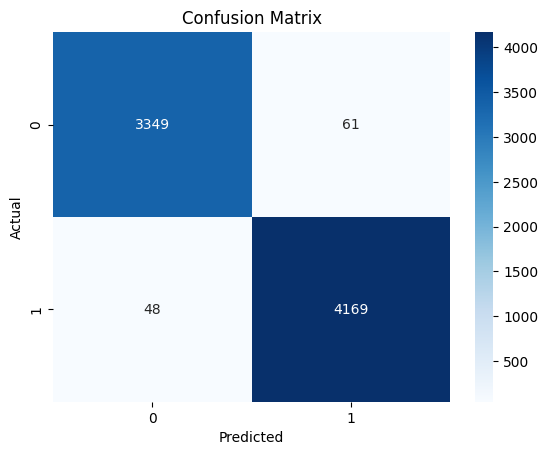

In [8]:
# Predict
y_pred = (model.predict(X_test) > 0.5).astype("int32")

# Metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


Plot accuracy and loss

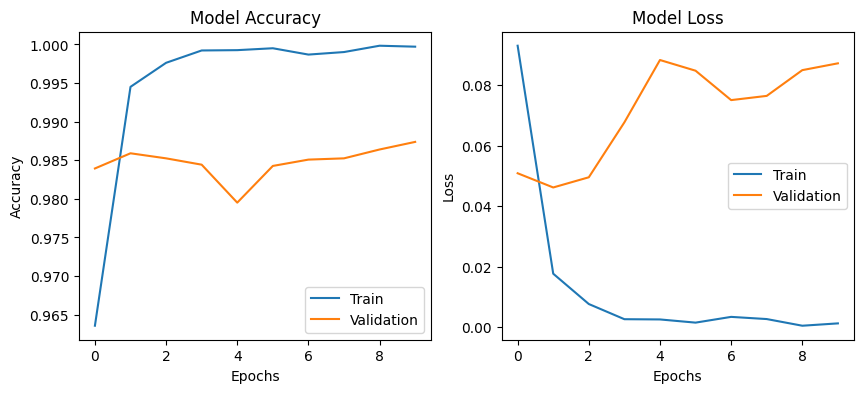

In [9]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


Try variations

Variation 1— more layers

In [10]:
model2 = keras.Sequential([
    layers.Dense(512, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dropout(0.5),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(1, activation='sigmoid')
])
model2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history1 = model2.fit(X_train, y_train, epochs=8, batch_size=32, validation_split=0.2)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/8
763/763 ━━━━━━━━━━━━━━━━━━━━ 18s 23ms/step - accuracy: 0.9711 - loss: 0.0869 - val_accuracy: 0.9871 - val_loss: 0.0398
Epoch 2/8
763/763 ━━━━━━━━━━━━━━━━━━━━ 17s 23ms/step - accuracy: 0.9941 - loss: 0.0187 - val_accuracy: 0.9816 - val_loss: 0.0516
Epoch 3/8
763/763 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.9973 - loss: 0.0085 - val_accuracy: 0.9872 - val_loss: 0.0483
Epoch 4/8
763/763 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.9986 - loss: 0.0037 - val_accuracy: 0.9864 - val_loss: 0.0622
Epoch 5/8
763/763 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.9989 - loss: 0.0033 - val_accuracy: 0.9843 - val_loss: 0.0723
Epoch 6/8
763/763 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.9991 - loss: 0.0035 - val_accuracy: 0.9851 - val_loss: 0.0684
Epoch 7/8
763/763 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.9992 - loss: 0.0024 - val_accuracy: 0.9848 - val_loss: 0.0794
Epoch 8/8
763/763 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.9996 - loss: 0.0013 - val_accu

Variation 2 — different optimizer

In [11]:



model3 = keras.Sequential([
    layers.Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])
model3.compile(optimizer='RMSprop', loss='binary_crossentropy', metrics=['accuracy'])
history2 = model3.fit(X_train, y_train, epochs=8, batch_size=32, validation_split=0.2)


Epoch 1/8
763/763 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9681 - loss: 0.0872 - val_accuracy: 0.9889 - val_loss: 0.0354
Epoch 2/8
763/763 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9946 - loss: 0.0190 - val_accuracy: 0.9893 - val_loss: 0.0309
Epoch 3/8
763/763 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9978 - loss: 0.0088 - val_accuracy: 0.9902 - val_loss: 0.0340
Epoch 4/8
763/763 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9991 - loss: 0.0032 - val_accuracy: 0.9895 - val_loss: 0.0377
Epoch 5/8
763/763 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9998 - loss: 0.0013 - val_accuracy: 0.9915 - val_loss: 0.0388
Epoch 6/8
763/763 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9999 - loss: 3.8292e-04 - val_accuracy: 0.9905 - val_loss: 0.0435
Epoch 7/8
763/763 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9999 - loss: 1.7601e-04 - val_accuracy: 0.9910 - val_loss: 0.0425
Epoch 8/8
763/763 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 1.0000 - loss: 6.8500e-05 - val_accuracy

In [12]:
user_input = input(" Enter a news headline or paragraph: ")
input_features = vectorizer.transform([user_input]).toarray()
prediction_prob = model.predict(input_features)[0][0]
prediction = 1 if prediction_prob > 0.5 else 0

if prediction == 1:
    print("\n The model predicts this news is REAL. (Probability: {:.2f})".format(prediction_prob))
else:
    print("\n The model predicts this news is FAKE. (Probability: {:.2f})".format(prediction_prob))

 Enter a news headline or paragraph: Priebus has been tapped to serve as Trumpâ€™s chief of staff when he starts his White House term Jan. 20, 2017. Christie had launched a presidential bid alongside Trump in a pool of 17 candidates that eventually saw Trump, a New York businessman who had never held political office, win the nomination as well as the Nov. 8 presidential election over Democrat Hillary Clinton.  Christie had been a rising political star before the so-called â€œBridgegateâ€ scandal involving his former top aides that left his reputation in tatters.   Pence took over from Christie, who at one time had been considered a possible candidate to serve as Trumpâ€™s attorney general, a post that instead went to U.S. Senator Jeff Sessions of Alabama. Trumpâ€™s team has said Christie would remain as vice chair of the transition effort. Earlier this month, Christieâ€™s two former aides were convicted for shutting down access lanes to the George Washington Bridge in 2013, creating 

In [13]:
df['label'].value_counts()



,count
label,
1,21181
0,16954


In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

#  Predict on test data
y_pred_prob = model3.predict(X_test)          # Probabilities (values between 0 and 1)
y_pred = (y_pred_prob > 0.5).astype(int)      # Convert to 0 or 1

#  Calculate main metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_prob)

# Print all results
print(" Model 3 Performance Metrics ")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")


239/239 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
 Model 3 Performance Metrics 
Accuracy: 0.9892
Precision: 0.9893
Recall: 0.9912
F1 Score: 0.9903
ROC-AUC: 0.9993


In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

#  Predict on test data
y_pred_prob = model2.predict(X_test)          # Probabilities (values between 0 and 1)
y_pred = (y_pred_prob > 0.5).astype(int)      # Convert to 0 or 1

#  Calculate main metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_prob)

#  Print all results
print("Model 3 Performance Metrics")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

239/239 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Model 3 Performance Metrics
Accuracy: 0.9877
Precision: 0.9840
Recall: 0.9938
F1 Score: 0.9889
ROC-AUC: 0.9988


In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

#  Predict on test data
y_pred_prob = model.predict(X_test)          # Probabilities (values between 0 and 1)
y_pred = (y_pred_prob > 0.5).astype(int)      # Convert to 0 or 1

#  Calculate main metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_prob)

# Print all results
print("Model 3 Performance Metrics")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

239/239 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
Model 3 Performance Metrics
Accuracy: 0.9857
Precision: 0.9856
Recall: 0.9886
F1 Score: 0.9871
ROC-AUC: 0.9986


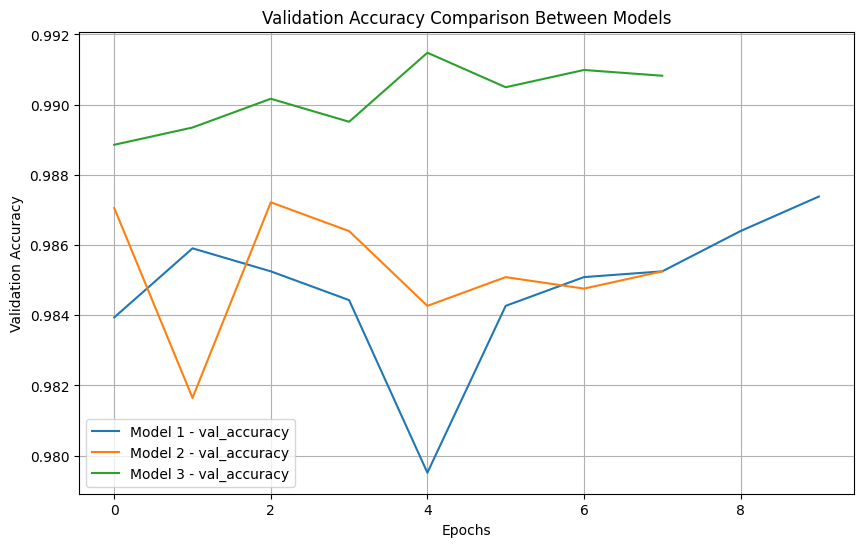

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(history.history['val_accuracy'], label='Model 1 - val_accuracy')
plt.plot(history1.history['val_accuracy'], label='Model 2 - val_accuracy')
plt.plot(history2.history['val_accuracy'], label='Model 3 - val_accuracy')

plt.title('Validation Accuracy Comparison Between Models')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [19]:
import joblib

# save vectorizer
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

# save model
model3.save("mlp_model.h5")

In [20]:
from google.colab import files
files.download("tfidf_vectorizer.pkl")
files.download("mlp_model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

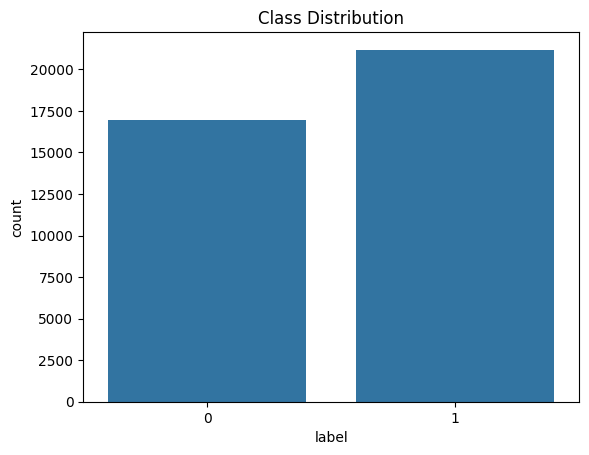

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='label', data=df)
plt.title("Class Distribution")
plt.show()

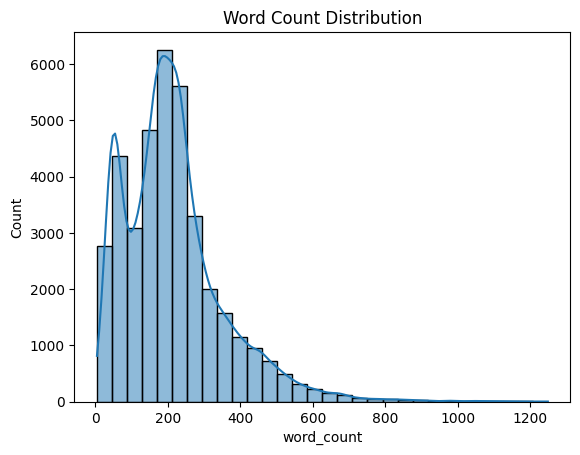

In [22]:
sns.histplot(df['word_count'], bins=30, kde=True)
plt.title("Word Count Distribution")
plt.show()

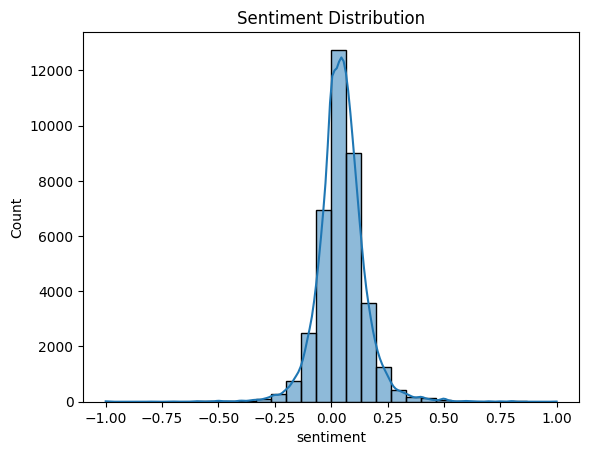

In [23]:
sns.histplot(df['sentiment'], bins=30, kde=True)
plt.title("Sentiment Distribution")
plt.show()

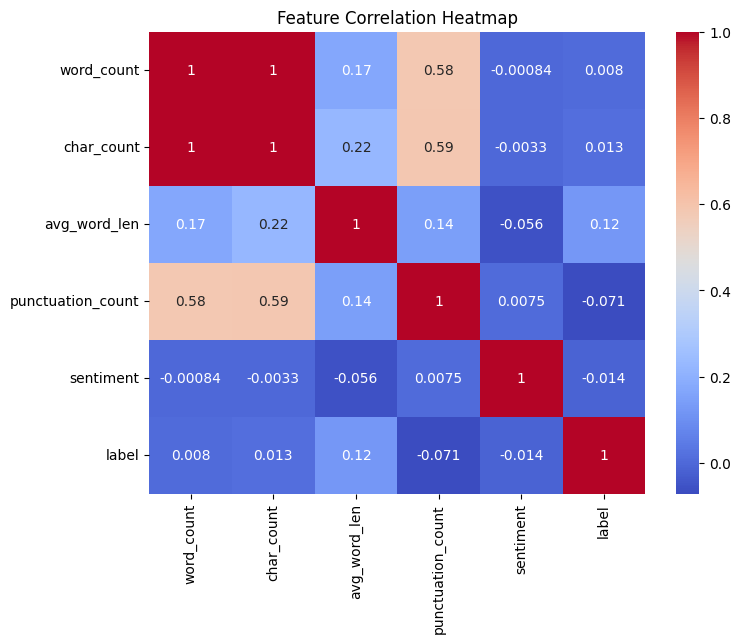

In [24]:
numeric_cols = ['word_count', 'char_count', 'avg_word_len', 'punctuation_count', 'sentiment', 'label']
corr = df[numeric_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()